In [1]:
import os
import time
import random
import warnings
from datetime import date
import gc

import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
from lxml import etree # type: ignore <- pylance milně hlásí chybu
from pathlib import Path
import time
import sys
import polars as pl
import polars.selectors as cs
import json
import pickle
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.patheffects as path_effects
from ydata_profiling import ProfileReport
import geopandas as gpd


current_dir = Path(__file__).resolve().parent if "__file__" in locals() else Path.cwd()
sys.path.append(str(current_dir.parent))
from utils import *
from schemas import *
from clean import *
from visualisation_utils import *

pl.Config.set_tbl_cols(-1)
os.chdir(r'E:\CVUT_BAP')
# os.chdir(r'C:\Users\adamp\Projects\CVUT_BAP')
SEED=42
PRINT = True
DATA_PATH = r"E:\CVUT_BAP\kod\data\processed\mereni.parquet"
TEMP_PATH = r"E:\CVUT_BAP\kod\data\processed\mereni.tmp.parquet"

# Načtení dat

In [2]:
df = pl.read_parquet(r'kod\data\extracted\data_z_mericich_pristroju\parquet', schema=mereni_schema)
describe(df, True)

CisloProtokolu,DatumProhlidky,StaniceCislo,Zahajeni,Ukonceni,OdpovednaOsoba,Prohlidka_CisloProtokolu,Prohlidka_DatumProhlidky,MericiPristroj_Vyrobce,MericiPristroj_Typ,MericiPristroj_Verze,MericiPristroj_OBD,MericiPristroj_VerzeSoftware,Poznamky,Vozidlo_Vin,Vozidlo_Znacka,Vozidlo_ObchodniOznaceni,Vozidlo_TypMotoru,Vozidlo_CisloMotoru,Vozidlo_Odometer,Vozidlo_RokVyroby,Vozidlo_DatumPrvniRegistrace,Vozidlo_Palivo,Vysledek_VisualniKontrola,Vysledek_Readiness,Vysledek_RidiciJednotka,Vysledek_RidiciJednotkaStav,Vysledek_Mil,Vysledek_TesnostPlynovehoZarizeni,Vysledek_Vyhovuje,PristiProhlidka,EmisniSystem,Obd_KomunikacniProtokol,Obd_Vin,Obd_PocetDtc,Obd_VzdalenostDtc,Obd_CasDtc,Obd_KontrolaMil,Obd_VypisDtc,Zavady,Obd_Readiness_Vysledek,Obd_Readiness_Zazeh_AC_Podporovano,Obd_Readiness_Zazeh_AC_Otestovano,Obd_Readiness_Zazeh_CAT-FUNC_Podporovano,Obd_Readiness_Zazeh_CAT-FUNC_Otestovano,Obd_Readiness_Zazeh_COMP_Podporovano,Obd_Readiness_Zazeh_COMP_Otestovano,Obd_Readiness_Zazeh_EGR-VVT_Podporovano,Obd_Readiness_Zazeh_EGR-VVT_Otestovano,Obd_Readiness_Zazeh_EVAP_Podporovano,Obd_Readiness_Zazeh_EVAP_Otestovano,Obd_Readiness_Zazeh_FUEL_Podporovano,Obd_Readiness_Zazeh_FUEL_Otestovano,Obd_Readiness_Zazeh_HCAT_Podporovano,Obd_Readiness_Zazeh_HCAT_Otestovano,Obd_Readiness_Zazeh_MISF_Podporovano,Obd_Readiness_Zazeh_MISF_Otestovano,Obd_Readiness_Zazeh_O2S-FUNC_Podporovano,Obd_Readiness_Zazeh_O2S-FUNC_Otestovano,Obd_Readiness_Zazeh_O2S-HEAT_Podporovano,Obd_Readiness_Zazeh_O2S-HEAT_Otestovano,Obd_Readiness_Zazeh_SAS_Podporovano,Obd_Readiness_Zazeh_SAS_Otestovano,Obd_Readiness_Vznet_AC_Podporovano,Obd_Readiness_Vznet_AC_Otestovano,Obd_Readiness_Vznet_BOOST_Podporovano,Obd_Readiness_Vznet_BOOST_Otestovano,Obd_Readiness_Vznet_COMP_Podporovano,Obd_Readiness_Vznet_COMP_Otestovano,Obd_Readiness_Vznet_DPF_Podporovano,Obd_Readiness_Vznet_DPF_Otestovano,Obd_Readiness_Vznet_EGR-VVT_Podporovano,Obd_Readiness_Vznet_EGR-VVT_Otestovano,Obd_Readiness_Vznet_EGS_Podporovano,Obd_Readiness_Vznet_EGS_Otestovano,Obd_Readiness_Vznet_FUEL_Podporovano,Obd_Readiness_Vznet_FUEL_Otestovano,Obd_Readiness_Vznet_MISF_Podporovano,Obd_Readiness_Vznet_MISF_Otestovano,Obd_Readiness_Vznet_NMHC_Podporovano,Obd_Readiness_Vznet_NMHC_Otestovano,Obd_Readiness_Vznet_NOX_Podporovano,Obd_Readiness_Vznet_NOX_Otestovano,Obd_Readiness_Vznet_RESERVE_Podporovano,Obd_Readiness_Vznet_RESERVE_Otestovano,Obd_Readiness_J1939_AC_Podporovano,Obd_Readiness_J1939_AC_Otestovano,Obd_Readiness_J1939_BOOST_Podporovano,Obd_Readiness_J1939_BOOST_Otestovano,Obd_Readiness_J1939_CAT-FUNC_Podporovano,Obd_Readiness_J1939_CAT-FUNC_Otestovano,Obd_Readiness_J1939_COLD_Podporovano,Obd_Readiness_J1939_COLD_Otestovano,Obd_Readiness_J1939_COMP_Podporovano,Obd_Readiness_J1939_COMP_Otestovano,Obd_Readiness_J1939_DPF_Podporovano,Obd_Readiness_J1939_DPF_Otestovano,Obd_Readiness_J1939_EGR-VVT_Podporovano,Obd_Readiness_J1939_EGR-VVT_Otestovano,Obd_Readiness_J1939_EGS-FUNC_Podporovano,Obd_Readiness_J1939_EGS-FUNC_Otestovano,Obd_Readiness_J1939_EGS-HEAT_Podporovano,Obd_Readiness_J1939_EGS-HEAT_Otestovano,Obd_Readiness_J1939_EVAP_Podporovano,Obd_Readiness_J1939_EVAP_Otestovano,Obd_Readiness_J1939_FUEL_Podporovano,Obd_Readiness_J1939_FUEL_Otestovano,Obd_Readiness_J1939_HCAT_Podporovano,Obd_Readiness_J1939_HCAT_Otestovano,Obd_Readiness_J1939_MISF_Podporovano,Obd_Readiness_J1939_MISF_Otestovano,Obd_Readiness_J1939_NM-HC_Podporovano,Obd_Readiness_J1939_NM-HC_Otestovano,Obd_Readiness_J1939_NOX_Podporovano,Obd_Readiness_J1939_NOX_Otestovano,Obd_Readiness_J1939_SAS_Podporovano,Obd_Readiness_J1939_SAS_Otestovano,Benzin_Palivo,Benzin_PocetVyusteni,Benzin_OtackyVolnobezne_CO_Max_Hodnota,Benzin_OtackyVolnobezne_CO_Max_RucniZadani,Benzin_OtackyVolnobezne_CO_Hodnota,Benzin_OtackyVolnobezne_CO_Vysledek,Benzin_OtackyVolnobezne_CO2_Hodnota,Benzin_OtackyVolnobezne_CO2_Vysledek,Benzin_OtackyVolnobezne_COCOOR_Hodnota,Benzin_OtackyVolnobezne_COCOOR_Vysledek,Benzin_OtackyVolnobezne_HC_Max_Hodnota,Benzin_OtackyVolnobezne_HC_Max_RucniZadani,Benzin_Otacky

(20537568, 321)


,CisloProtokolu,DatumProhlidky,StaniceCislo,Zahajeni,Ukonceni,OdpovednaOsoba,Prohlidka_CisloProtokolu,Prohlidka_DatumProhlidky,MericiPristroj_Vyrobce,MericiPristroj_Typ,...,Plyn_OtackyZvysene_NOX_Hodnota,Plyn_OtackyZvysene_NOX_Vysledek,Plyn_OtackyZvysene_O2_Hodnota,Plyn_OtackyZvysene_O2_Vysledek,Plyn_OtackyZvysene_TPS_Hodnota,Plyn_OtackyZvysene_TPS_Vysledek,Plyn_Nadrz_Vyrobce,Plyn_Nadrz_Homologace,Plyn_Nadrz_Zivotnost,Plyn_Nadrz_Kontrola
0,CZ-420930-19-01-0001,2019-01-01,420930,2019-01-01T14:43:55.0200000+01:00,2019-01-01T15:06:04.3900000+01:00,47287,CZ-420930-19-01-0001,2019-01-01T14:51:00,ActiaCZ,AT605,...,None,None,None,None,None,None,None,None,None,None
1,CZ-520406-19-01-0001,2019-01-01,520406,2019-01-01T15:22:33.2900000+01:00,2019-01-01T15:39:51.5500000+01:00,16835,CZ-520406-19-01-0001,2019-01-01T15:27:00,AVL DiTEST GmbH,AVL DiSmoke 480,...,None,None,None,None,None,None,None,None,None,None
2,CZ-170901-23-01-0002,2023-01-01,170901,2023-01-01T19:42:08.8770000+01:00,2023-01-01T19:53:03.3100000+01:00,89493,CZ-170901-23-01-0002,2023-01-01T19:50:00,MAHLE,OPA-100,...,None,None,None,None,None,None,None,None,None,None
3,CZ-480811-23-01-0001,2023-01-01,480811,2023-01-01T12:22:13.5700000+01:00,2023-01-01T12:36:18.7000000+01:00,36479,CZ-480811-23-01-0001,2023-01-01T12:33:00,MAHLE,OPA-100,...,None,None,None,None,None,None,None,None,None,None
4,CZ-420221-23-01-0001,2023-01-01,420221,2023-01-01T16:07:06.1270000+01:00,2023-01-01T16:17:16.0300000+01:00,44365,CZ-420221-23-01-0001,2023-01-01T16:17:00,ACTIA CZ s.r.o.,AT605,...,None,None,None,None,None,None,None,None,None,None
5,CZ-420221-23-01-0003,2023-01-01,420221,2023-01-01T16:57:28.1900000+01:00,2023-01-01T17:06:11.8300000+01:00,44365,CZ-420221-23-01-0003,2023-01-01T17:05:00,ACTIA CZ s.r.o.,AT605,...,None,None,None,None,None,None,None,None,None,None
6,CZ-170901-23-01-0001,2023-01-01,170901,2023-01-01T19:24:30.3070000+01:00,2023-01-01T19:36:25.5270000+01:00,89493,CZ-170901-23-01-0001,2023-01-01T19:32:00,MAHLE,OPA-100,...,None,None,None,None,None,None,None,None,None,None
7,CZ-420221-23-01-0004,2023-01-01,420221,2023-01-01T17:26:23.7170000+01:00,2023-01-01T17:41:10.1600000+01:00,44365,CZ-420221-23-01-0004,2023-01-01T17:40:00,ACTIA CZ s.r.o.,AT605,...,None,None,None,None,None,None,None,None,None,None
8,CZ-520406-24-01-0001,2024-01-01,520406,2024-01-01T11:31:17.2900000+01:00,2024-01-01T11:48:07.5200000+01:00,1308,CZ-520406-24-01-0001,2024-01-01T11:38:00,AVL DiTEST GmbH,AVL Gas 1000,...,None,None,None,None,None,None,None,None,None,None
9,CZ-480811-24-01-0001,2024-01-01,480811,2024-01-01T16:22:23.1070000+01:00,2024-01-01T16:36:09.9300000+01:00,36479,CZ-480811-24-01-0001,2024-01-01T16:31:00,MAHLE,OPA-100,...,None,None,None,None,None,None,None,None,None,None


# Přetypování sloupců

In [3]:
df = cast_mereni(df)
df.write_parquet(DATA_PATH)
del df

# Optimalizacni operace

In [ ]:
def trans_oom(transform_fn):
    def execute_stream():
        lf = pl.scan_parquet(DATA_PATH)
        transformed_lf = transform_fn(lf)
        transformed_lf.sink_parquet(TEMP_PATH)

    execute_stream()
    
    # Garbage collect to force release any lingering file handles
    gc.collect()
    os.replace(TEMP_PATH, DATA_PATH)

def get_lf():
    return pl.scan_parquet(DATA_PATH)

def get_df():
    return pl.read_parquet(DATA_PATH)

def save_df(df):
    df.write_parquet(DATA_PATH)

# Unikatnost cisla protokolu

In [ ]:
print(f'Délka datasetu před odstraněním duplicitních řádků: {get_lf().select(pl.len()).collect().item()}')

trans_oom(lambda lf: lf.unique())
print(f'Délka datasetu po odstranění duplicitních řádků: {get_lf().select(pl.len()).collect().item()}')

non_unique = get_lf().select(pl.col('CisloProtokolu')).filter(pl.col('CisloProtokolu').is_duplicated()).collect()['CisloProtokolu'].unique().to_list()
short_display(get_lf().filter(pl.col('CisloProtokolu').is_in(non_unique)).collect(engine='streaming').sort(by=['CisloProtokolu', 'StaniceCislo']))

trans_oom(lambda lf: lf.filter(~pl.col('CisloProtokolu').is_in(non_unique) | (pl.col('CisloProtokolu').str.split('-').list.get(1).cast(pl.Int32) == pl.col("StaniceCislo"))))
print(f'Délka datasetu po odstranění vsech duplicitnich cisel protokolu: {get_lf().select(pl.len()).collect().item()}')

Délka datasetu před odstraněním duplicitních řádků: 20537568
Délka datasetu po odstranění duplicitních řádků: 20536729
(8, 321)


,CisloProtokolu,DatumProhlidky,StaniceCislo,Zahajeni,Ukonceni,OdpovednaOsoba,Prohlidka_CisloProtokolu,Prohlidka_DatumProhlidky,MericiPristroj_Vyrobce,MericiPristroj_Typ,...,Plyn_OtackyZvysene_NOX_Hodnota,Plyn_OtackyZvysene_NOX_Vysledek,Plyn_OtackyZvysene_O2_Hodnota,Plyn_OtackyZvysene_O2_Vysledek,Plyn_OtackyZvysene_TPS_Hodnota,Plyn_OtackyZvysene_TPS_Vysledek,Plyn_Nadrz_Vyrobce,Plyn_Nadrz_Homologace,Plyn_Nadrz_Zivotnost,Plyn_Nadrz_Kontrola
0,CZ-540308-24-02-0512,2024-02-14,3420,2024-02-14 06:53:19.297,2024-02-14 07:09:35.900,69281,CZ-540308-24-02-0512,2024-02-14 07:08:34.888717,Bosch,BEA 950,...,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,None
1,CZ-540308-24-02-0512,2024-02-14,540308,2024-02-14 06:53:19.297,2024-02-14 07:09:35.900,102209,CZ-540308-24-02-0512,2024-02-14 07:08:34.888717,Bosch,BEA 950,...,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,None
2,CZ-540308-24-02-0561,2024-02-15,3420,2024-02-15 06:49:41.327,2024-02-15 07:11:41.980,24305,CZ-540308-24-02-0561,2024-02-15 07:08:35.424907,Bosch,BEA050,...,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,None
3,CZ-540308-24-02-0561,2024-02-15,540308,2024-02-15 06:49:41.327,2024-02-15 07:11:41.980,102209,CZ-540308-24-02-0561,2024-02-15 07:08:35.424907,Bosch,BEA050,...,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,None
4,CZ-540308-24-02-0563,2024-02-15,3420,2024-02-15 07:26:23.013,2024-02-15 07:47:24.537,24305,CZ-540308-24-02-0563,2024-02-15 07:34:39.047436,Bosch,BEA050,...,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,None
5,CZ-540308-24-02-0563,2024-02-15,540308,2024-02-15 07:26:23.013,2024-02-15 07:47:24.537,102209,CZ-540308-24-02-0563,2024-02-15 07:34:39.047436,Bosch,BEA050,...,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,None
6,CZ-550309-23-06-0452,2023-06-14,3521,2023-06-14 14:29:49.537,2023-06-14 15:01:31.037,3329,CZ-550309-23-06-0452,2023-06-14 14:50:00.000000,MAHLE,OPA-100,...,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,None
7,CZ-550309-23-06-0452,2023-06-14,550309,2023-06-14 14:29:49.537,2023-06-14 15:01:31.037,2565,CZ-550309-23-06-0452,2023-06-14 14:50:00.000000,MAHLE,OPA-100,...,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,None


PermissionError: [WinError 5] Access is denied: 'E:\\CVUT_BAP\\kod\\data\\processed\\mereni.tmp.parquet' -> 'E:\\CVUT_BAP\\kod\\data\\processed\\mereni.parquet'

In [ ]:
# trans_oom(lambda lf: lf.filter(~pl.col('CisloProtokolu').is_in(non_unique) | (pl.col('CisloProtokolu').str.split('-').list.get(1).cast(pl.Int32) == pl.col("StaniceCislo"))))
# print(f'Délka datasetu po odstranění vsech duplicitnich cisel protokolu: {get_lf().select(pl.len()).collect().item()}')

Délka datasetu po odstranění vsech duplicitnich cisel protokolu: 20536725


# Vyber mereni, ktera maji protejsek v prohlidkach (zajisteni stejnych filtru)

In [8]:
df = get_df()
lf_prohlidky = pl.scan_parquet(r'E:\CVUT_BAP\kod\data\processed\prohlidky.parquet')
id_prohlidky_series = lf_prohlidky.select('CisloProtokolu').unique().collect(engine='streaming').get_column('CisloProtokolu')
id_prohlidky = set(id_prohlidky_series)
id_mereni = set(df.get_column('CisloProtokolu'))
orphan = list(id_prohlidky - id_mereni)
lf_prohlidky.filter(pl.col('CisloProtokolu').is_in(orphan)).collect(engine='streaming')['DatumProhlidky'].value_counts(sort=True)

DatumProhlidky,count
date,u32
2026-02-27,7298
2025-03-31,1
2024-11-20,1
2024-10-30,1
2020-12-08,1


In [9]:
df = df.join(id_prohlidky_series.to_frame("CisloProtokolu"), on="CisloProtokolu", how="semi")

# Odstraneni nekterych sloupcu
### Rok_vyroby

In [10]:
print(f'Podil mereni, ktera maji rok vyroby mensi nez 1000: {len(df.filter(pl.col('Vozidlo_RokVyroby') < 1000)) / df.height * 100:.2f} %')

Podil mereni, ktera maji rok vyroby mensi nez 1000: 25.64 %


### Vysledek_RidiciJednotka

In [11]:
print(df.select('Vysledek_RidiciJednotkaStav', 'Vysledek_RidiciJednotka').filter(pl.col('Vysledek_RidiciJednotkaStav') == 1)['Vysledek_RidiciJednotka'].value_counts(sort=True)['Vysledek_RidiciJednotka'].to_list()[:10])
print(df.select('Vysledek_RidiciJednotkaStav', 'Vysledek_RidiciJednotka').filter(pl.col('Vysledek_RidiciJednotkaStav') == 2)['Vysledek_RidiciJednotka'].value_counts(sort=True)['Vysledek_RidiciJednotka'].to_list()[:10])
print(df.select('Vysledek_RidiciJednotkaStav', 'Vysledek_RidiciJednotka').filter(pl.col('Vysledek_RidiciJednotkaStav') == 3)['Vysledek_RidiciJednotka'].value_counts(sort=True)['Vysledek_RidiciJednotka'].to_list()[:10])

['---', 'bez závad', '', None, 'Celkem 0 závad ', 'Bez závad', 'BEZ ZÁVAD', 'OK', 'ok', 'Nebyly zjištěny závady']
['---', None, '', 'BEZ ZÁVAD', 'OK', 'bez závad', 'BEZ ZAVAD', 'Bez závad', 'ok', 'Nebyly zjištěny závady']
['---', None, 'emisně relevantní závady', '', 'Bez závad', 'Celkem 1 závada P0380', 'Celkem Chybová hlášení v paměti. závad ', 'Celkem 1 závada P0420', 'Celkem 1 závada P0401', 'Celkem 1 závada P0121']


### Obd_VypisDTC

In [12]:
obd_vypis_dtc_non_null = df['Obd_VypisDtc'].filter(df['Obd_VypisDtc'].is_not_null())
print(f'Podil, kdy obd vypis dtc neni null: {len(obd_vypis_dtc_non_null) / df.height * 100:.2f} %')
print(obd_vypis_dtc_non_null.to_list()[:10])

Podil, kdy obd vypis dtc neni null: 2.73 %
[['P0471'], ['P2096'], ['P1351'], ['P0490'], ['P0351'], ['P0380'], ['P0136'], ['P1178', 'P0135'], ['P0122', 'P0202', 'P0204', 'P0203', 'P0201'], ['P14A7']]


### J1939
- Odstraneni radku, ktere hodnoty obsahuji

In [13]:
j1939_df = df.filter(
    pl.any_horizontal(
        pl.col("^.*J1939.*$").is_not_null()
    )
)
short_display(j1939_df)
# Modifikace df
df = df.join(j1939_df, on="CisloProtokolu", how="anti")

(120, 321)


,CisloProtokolu,DatumProhlidky,StaniceCislo,Zahajeni,Ukonceni,OdpovednaOsoba,Prohlidka_CisloProtokolu,Prohlidka_DatumProhlidky,MericiPristroj_Vyrobce,MericiPristroj_Typ,...,Plyn_OtackyZvysene_NOX_Hodnota,Plyn_OtackyZvysene_NOX_Vysledek,Plyn_OtackyZvysene_O2_Hodnota,Plyn_OtackyZvysene_O2_Vysledek,Plyn_OtackyZvysene_TPS_Hodnota,Plyn_OtackyZvysene_TPS_Vysledek,Plyn_Nadrz_Vyrobce,Plyn_Nadrz_Homologace,Plyn_Nadrz_Zivotnost,Plyn_Nadrz_Kontrola
0,CZ-3215-25-12-0251,2025-12-04,3215,2025-12-04 11:50:05.090,2025-12-04 11:58:21.693,24941,CZ-3215-25-12-0251,2025-12-04 11:50:05.000000,AVL DiTEST GmbH,AVL DiSmoke 480,...,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,None
1,CZ-580508-23-06-0062,2023-06-07,580508,2023-06-07 08:08:42.600,2023-06-07 08:15:00.807,37019,CZ-580508-23-06-0062,2023-06-07 08:03:00.000000,AVL DiTEST GmbH,AVL DiSmoke 480,...,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,None
2,CZ-430519-25-08-0075,2025-08-19,430519,2025-08-19 08:06:11.753,2025-08-19 08:29:09.327,3963,CZ-430519-25-08-0075,2025-08-19 08:24:00.000000,ATAL s.r.o.,AT605,...,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,None
3,CZ-561008-25-10-0065,2025-10-07,561008,2025-10-07 09:23:57.393,2025-10-07 09:33:00.387,15365,CZ-561008-25-10-0065,2025-10-07 09:23:57.000000,AVL DiTEST GmbH,AVL DiSmoke 480,...,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,None
4,CZ-560613-22-09-0398,2022-09-16,560613,2022-09-16 16:55:12.947,2022-09-16 17:05:06.717,21187,CZ-560613-22-09-0398,2022-09-16 16:55:13.000000,AVL DiTEST GmbH,AVL Gas 1000,...,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,None
5,CZ-511010-21-03-0136,2021-03-18,511010,2021-03-18 10:07:10.053,2021-03-18 10:20:46.967,52815,CZ-511010-21-03-0136,2021-03-18 10:20:00.000000,BRAIN BEE,OPA-100,...,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,None
6,CZ-550501-25-04-0227,2025-04-29,550501,2025-04-29 07:58:20.393,2025-04-29 08:12:53.900,41491,CZ-550501-25-04-0227,2025-04-29 08:12:48.001170,Bosch,BEA070,...,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,None
7,CZ-450543-23-05-0080,2023-05-03,450543,2023-05-03 12:02:26.893,2023-05-03 12:09:03.813,42997,CZ-450543-23-05-0080,2023-05-03 12:07:00.000000,MAHLE,OPA-100,...,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,None
8,CZ-120902-21-03-0076,2021-03-08,120902,2021-03-08 11:49:47.300,2021-03-08 12:02:59.210,84501,CZ-120902-21-03-0076,2021-03-08 12:02:00.000000,BRAIN BEE,OPA-100,...,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,None
9,CZ-420821-22-03-0430,2022-03-14,420821,2022-03-14 14:40:46.507,2022-03-14 15:08:59.013,6803,CZ-420821-22-03-0430,2022-03-14 14:45:00.000000,AVL DiTEST GmbH,AVL DiSmoke 480,...,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,None


### Plyn_PocetVyusteni

In [14]:
df['Plyn_PocetVyusteni'].value_counts()

Plyn_PocetVyusteni,count
i8,u32
0,16211224


### PristiProhlidka

In [15]:
df.filter(pl.col('PristiProhlidka').is_not_null())['Vysledek_Vyhovuje'].value_counts()

Vysledek_Vyhovuje,count
bool,u32
true,15798700


In [ ]:
duplicate_cols = ['DatumProhlidky', 'StaniceCislo', 'Zahajeni', 'Ukonceni', 'OdpovednaOsoba', 'Prohlidka_DatumProhlidky', 'Vozidlo_Vin', 'Vozidlo_Znacka', 'Vozidlo_ObchodniOznaceni', 'Vozidlo_TypMotoru', 'Vozidlo_CisloMotoru', 'Vozidlo_Odometer', 'Vozidlo_DatumPrvniRegistrace', 'Vozidlo_Palivo', 'Obd_Vin']
irrelevant_cols = ['Prohlidka_CisloProtokolu', 'Vozidlo_RokVyroby', 'Vysledek_RidiciJednotka', 'Vysledek_TesnostPlynovehoZarizeni', 'PristiProhlidka', 'Benzin_Palivo', 'Nafta_Palivo']
j1939_cols = ['Obd_Readiness_J1939_AC_Podporovano', 'Obd_Readiness_J1939_AC_Otestovano', 'Obd_Readiness_J1939_BOOST_Podporovano', 'Obd_Readiness_J1939_BOOST_Otestovano', 'Obd_Readiness_J1939_CAT-FUNC_Podporovano', 'Obd_Readiness_J1939_CAT-FUNC_Otestovano', 'Obd_Readiness_J1939_COLD_Podporovano', 'Obd_Readiness_J1939_COLD_Otestovano', 'Obd_Readiness_J1939_COMP_Podporovano', 'Obd_Readiness_J1939_COMP_Otestovano', 'Obd_Readiness_J1939_DPF_Podporovano', 'Obd_Readiness_J1939_DPF_Otestovano', 'Obd_Readiness_J1939_EGR-VVT_Podporovano', 'Obd_Readiness_J1939_EGR-VVT_Otestovano', 'Obd_Readiness_J1939_EGS-FUNC_Podporovano', 'Obd_Readiness_J1939_EGS-FUNC_Otestovano', 'Obd_Readiness_J1939_EGS-HEAT_Podporovano', 'Obd_Readiness_J1939_EGS-HEAT_Otestovano', 'Obd_Readiness_J1939_EVAP_Podporovano', 'Obd_Readiness_J1939_EVAP_Otestovano', 'Obd_Readiness_J1939_FUEL_Podporovano', 'Obd_Readiness_J1939_FUEL_Otestovano', 'Obd_Readiness_J1939_HCAT_Podporovano', 'Obd_Readiness_J1939_HCAT_Otestovano', 'Obd_Readiness_J1939_MISF_Podporovano', 'Obd_Readiness_J1939_MISF_Otestovano', 'Obd_Readiness_J1939_NM-HC_Podporovano', 'Obd_Readiness_J1939_NM-HC_Otestovano', 'Obd_Readiness_J1939_NOX_Podporovano', 'Obd_Readiness_J1939_NOX_Otestovano', 'Obd_Readiness_J1939_SAS_Podporovano', 'Obd_Readiness_J1939_SAS_Otestovano']
plyn_cols = ['Plyn_Palivo', 'Plyn_PocetVyusteni', 'Plyn_OtackyVolnobezne_CO_Max_Hodnota', 'Plyn_OtackyVolnobezne_CO_Max_RucniZadani', 'Plyn_OtackyVolnobezne_CO_Hodnota', 'Plyn_OtackyVolnobezne_CO_Vysledek', 'Plyn_OtackyVolnobezne_CO2_Hodnota', 'Plyn_OtackyVolnobezne_CO2_Vysledek', 'Plyn_OtackyVolnobezne_COCOOR_Hodnota', 'Plyn_OtackyVolnobezne_COCOOR_Vysledek', 'Plyn_OtackyVolnobezne_HC_Max_Hodnota', 'Plyn_OtackyVolnobezne_HC_Max_RucniZadani', 'Plyn_OtackyVolnobezne_HC_Hodnota', 'Plyn_OtackyVolnobezne_HC_Vysledek', 'Plyn_OtackyVolnobezne_LAMBDA_Min_Hodnota', 'Plyn_OtackyVolnobezne_LAMBDA_Min_RucniZadani', 'Plyn_OtackyVolnobezne_LAMBDA_Max_Hodnota', 'Plyn_OtackyVolnobezne_LAMBDA_Max_RucniZadani', 'Plyn_OtackyVolnobezne_LAMBDA_Hodnota', 'Plyn_OtackyVolnobezne_LAMBDA_Vysledek', 'Plyn_OtackyVolnobezne_N_Min_Hodnota', 'Plyn_OtackyVolnobezne_N_Min_RucniZadani', 'Plyn_OtackyVolnobezne_N_Max_Hodnota', 'Plyn_OtackyVolnobezne_N_Max_RucniZadani', 'Plyn_OtackyVolnobezne_N_Hodnota', 'Plyn_OtackyVolnobezne_N_Vysledek', 'Plyn_OtackyVolnobezne_NOX_Hodnota', 'Plyn_OtackyVolnobezne_NOX_Vysledek', 'Plyn_OtackyVolnobezne_O2_Hodnota', 'Plyn_OtackyVolnobezne_O2_Vysledek', 'Plyn_OtackyVolnobezne_TPS_Hodnota', 'Plyn_OtackyVolnobezne_TPS_Vysledek', 'Plyn_OtackyZvysene_CO_Max_Hodnota', 'Plyn_OtackyZvysene_CO_Max_RucniZadani', 'Plyn_OtackyZvysene_CO_Hodnota', 'Plyn_OtackyZvysene_CO_Vysledek', 'Plyn_OtackyZvysene_CO2_Hodnota', 'Plyn_OtackyZvysene_CO2_Vysledek', 'Plyn_OtackyZvysene_COCOOR_Hodnota', 'Plyn_OtackyZvysene_COCOOR_Vysledek', 'Plyn_OtackyZvysene_HC_Max_Hodnota', 'Plyn_OtackyZvysene_HC_Max_RucniZadani', 'Plyn_OtackyZvysene_HC_Hodnota', 'Plyn_OtackyZvysene_HC_Vysledek', 'Plyn_OtackyZvysene_LAMBDA_Min_Hodnota', 'Plyn_OtackyZvysene_LAMBDA_Min_RucniZadani', 'Plyn_OtackyZvysene_LAMBDA_Max_Hodnota', 'Plyn_OtackyZvysene_LAMBDA_Max_RucniZadani', 'Plyn_OtackyZvysene_LAMBDA_Hodnota', 'Plyn_OtackyZvysene_LAMBDA_Vysledek', 'Plyn_OtackyZvysene_N_Min_Hodnota', 'Plyn_OtackyZvysene_N_Min_RucniZadani', 'Plyn_OtackyZvysene_N_Max_Hodnota', 'Plyn_OtackyZvysene_N_Max_RucniZadani', 'Plyn_OtackyZvysene_N_Hodnota', 'Plyn_OtackyZvysene_N_Vysledek', 'Plyn_OtackyZvysene_NOX_Hodnota', 'Plyn_OtackyZvysene_NOX_Vysledek', 'Plyn_OtackyZvysene_O2_Hodnota', 'Plyn_OtackyZvysene_O2_Vysledek', 'Plyn_OtackyZvysene_TPS_Hodnota', 'Plyn_OtackyZvysene_TPS_Vysledek', 'Plyn_Nadrz_Vyrobce', 'Plyn_Nadrz_Homologace', 'Plyn_Nadrz_Zivotnost', 'Plyn_Nadrz_Kontrola']
df = df.drop(duplicate_cols + irrelevant_cols + j1939_cols + plyn_cols)

# Serazeni sloupcu podle textu prace

In [20]:
df = df.select([
    # Identifikace měření
    "CisloProtokolu",

    # Měřicí přístroj
    "MericiPristroj_Vyrobce",
    "MericiPristroj_Typ",
    "MericiPristroj_Verze",
    "MericiPristroj_OBD",
    "MericiPristroj_VerzeSoftware",

    # Výsledek měření
    "Vysledek_VisualniKontrola",
    "Vysledek_Readiness",
    "Vysledek_RidiciJednotkaStav",
    "Vysledek_Mil",
    "Vysledek_Vyhovuje",
    "Obd_Readiness_Vysledek",
    "Zavady",
    "Poznamky",

    # Emisní systém (rizenyOBD)
    "EmisniSystem",
    "Obd_KomunikacniProtokol",
    "Obd_KontrolaMil",
    "Obd_PocetDtc",
    "Obd_VypisDtc",
    "Obd_VzdalenostDtc",
    "Obd_CasDtc",
    *sorted([c for c in df.columns if "Obd_Readiness_Zazeh" in c]),
    *sorted([c for c in df.columns if "Obd_Readiness_Vznet" in c]),

    # Detail měření dle typu paliva - Benzin
    "Benzin_PocetVyusteni",
    *sorted([c for c in df.columns if c.startswith("Benzin_OtackyVolnobezne")]),
    *sorted([c for c in df.columns if c.startswith("Benzin_OtackyZvysene")]),

    # Detail měření dle typu paliva - Nafta
    "Nafta_PocetVyusteni",
    *sorted([c for c in df.columns if c.startswith("Nafta_MereniVznetLimit")]),
    *sorted([c for c in df.columns if c.startswith("Nafta_MereniPrumer")]),
    *sorted([c for c in df.columns if c.startswith("Nafta_Mereni0")]),
    *sorted([c for c in df.columns if c.startswith("Nafta_Mereni1")]),
    *sorted([c for c in df.columns if c.startswith("Nafta_Mereni2")]),
    *sorted([c for c in df.columns if c.startswith("Nafta_Mereni3")])
])
# save_df(df)

In [21]:
schema_description(df)
df.write_parquet(r"E:\CVUT_BAP\kod\data\processed\mereni_tmp.parquet")

,column,majority_class,majority_cnt,null,dtype
0,CisloProtokolu,CZ-460257-23-04-0476,1 / 16 211 224,0 / 16 211 224,String
1,MericiPristroj_Vyrobce,Bosch,5 375 898 / 16 211 224,19 781 / 16 211 224,String
2,MericiPristroj_Typ,AT505,2 376 466 / 16 211 224,19 781 / 16 211 224,String
3,MericiPristroj_Verze,-,5 642 738 / 16 211 224,723 589 / 16 211 224,String
4,MericiPristroj_OBD,R+OBD,3 262 784 / 16 211 224,1 942 264 / 16 211 224,String
...,...,...,...,...,...
196,Nafta_Mereni3_OtackyVolnobezne_Vysledek,1,2 370 450 / 16 211 224,13 839 884 / 16 211 224,Int8
197,Nafta_Mereni3_TPS_Hodnota,0.0,1 250 177 / 16 211 224,14 578 098 / 16 211 224,Float32
198,Nafta_Mereni3_TPS_Vysledek,2,1 597 033 / 16 211 224,14 578 098 / 16 211 224,Int8
199,Nafta_Mereni3_Teplota_Hodnota,0.0,425 610 / 16 211 224,14 244 049 / 16 211 224,Float32


# Chybejici hodnoty

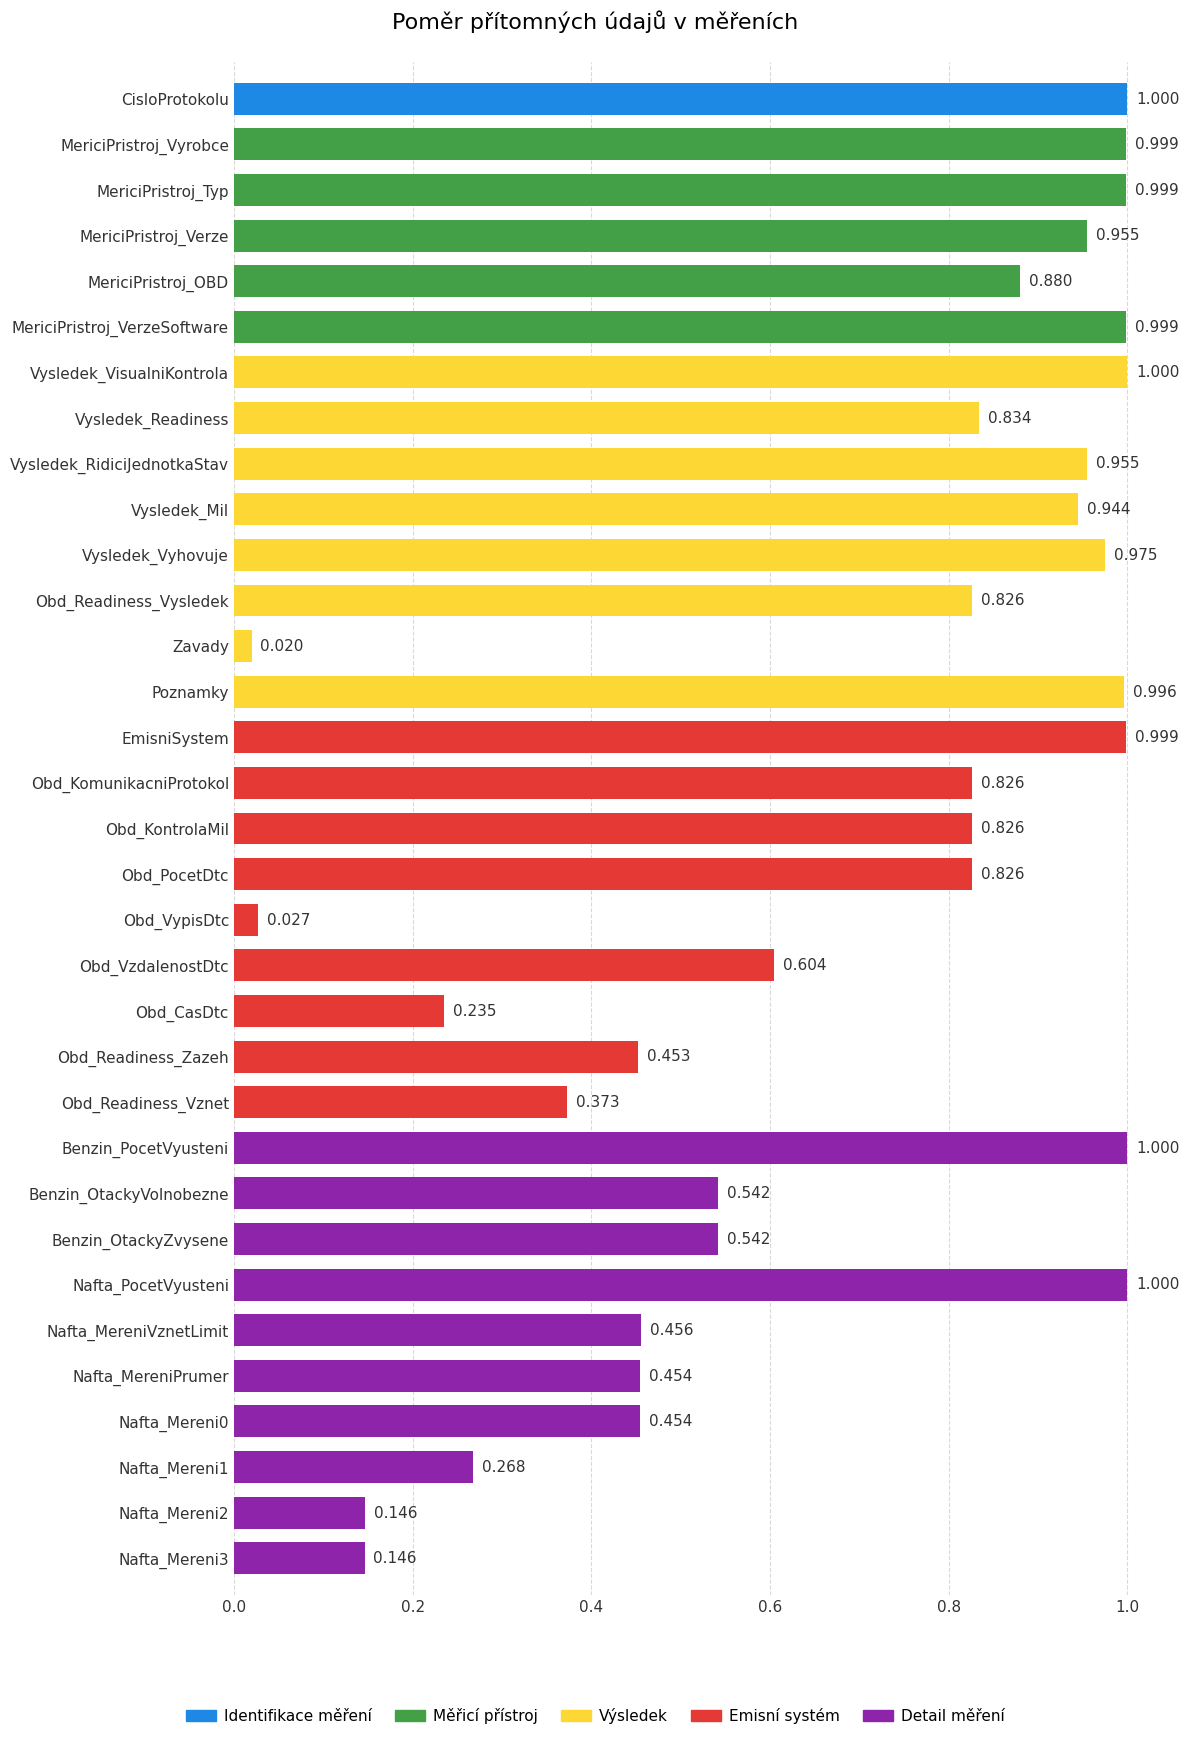

In [ ]:
# Definice agregačních skupin
aggregation_groups = {
    'Obd_Readiness_Zazeh': [c for c in df.columns if 'Obd_Readiness_Zazeh' in c],
    'Obd_Readiness_Vznet': [c for c in df.columns if 'Obd_Readiness_Vznet' in c],
    'Benzin_OtackyVolnobezne': [c for c in df.columns if c.startswith('Benzin_OtackyVolnobezne_')],
    'Benzin_OtackyZvysene': [c for c in df.columns if c.startswith('Benzin_OtackyZvysene_')],
    'Nafta_MereniVznetLimit': [c for c in df.columns if c.startswith('Nafta_MereniVznetLimit_')],
    'Nafta_MereniPrumer': [c for c in df.columns if c.startswith('Nafta_MereniPrumer_')],
    'Nafta_Mereni0': [c for c in df.columns if c.startswith('Nafta_Mereni0_')],
    'Nafta_Mereni1': [c for c in df.columns if c.startswith('Nafta_Mereni1_')],
    'Nafta_Mereni2': [c for c in df.columns if c.startswith('Nafta_Mereni2_')],
    'Nafta_Mereni3': [c for c in df.columns if c.startswith('Nafta_Mereni3_')],
}

# Inverzní mapování: sloupec -> název skupiny
col_to_group = {col: g_name for g_name, g_cols in aggregation_groups.items() for col in g_cols}

# Výpočet metrik se zachováním pořadí z df.columns
total_rows = len(df)
final_labels = []
final_ratios = []
processed_groups = set()

for col in df.columns:
    if col in col_to_group:
        group_name = col_to_group[col]
        if group_name not in processed_groups:
            # Výpočet pro celou skupinu (aspoň jedna ne-null hodnota)
            group_cols = aggregation_groups[group_name]
            any_present_count = df.select(
                pl.any_horizontal(pl.col(group_cols).is_not_null())
            ).sum().item()
            final_labels.append(group_name)
            final_ratios.append(any_present_count / total_rows if total_rows > 0 else 0)
            processed_groups.add(group_name)
    else:
        # Samostatný sloupec
        non_null_count = total_rows - df[col].null_count()
        final_labels.append(col)
        final_ratios.append(non_null_count / total_rows if total_rows > 0 else 0)

# Kategorizace (6 skupin včetně Vozidla)
group_descriptions = [
    'Identifikace měření',
    'Měřicí přístroj',
    'Výsledek',  
    'Emisní systém', 
    'Detail měření'  
]

def map_to_main_category(label):
    if label == 'CisloProtokolu': return 0
    if label.startswith('MericiPristroj'): return 1
    if any(x in label for x in ['Vysledek', 'PristiProhlidka', 'Zavady', 'Poznamky']): return 2
    if label.startswith('EmisniSystem') or label.startswith('Obd'): return 3
    if label.startswith('Benzin') or label.startswith('Nafta'): return 4
    return 3

group_indices = [map_to_main_category(l) for l in final_labels]

# Generování grafu
horizontal_bar(
    labels=final_labels, 
    counts=final_ratios, 
    title='Poměr přítomných údajů v měřeních', 
    save_path='kod/explorace/mereni_grafy/mereni_pritomnost.svg', 
    decimals=3, 
    height=18, 
    group_indices=group_indices, 
    group_descriptions=group_descriptions
)

### Emisni systemy

In [26]:
df['EmisniSystem'].value_counts(sort=True).with_columns(pl.col('count') / df.height)

EmisniSystem,count
enum,f64
"""Rizeny_Obd""",0.825958
"""Rizeny""",0.159702
"""Nerizeny""",0.01312
null,0.00122


### Pocet mereni u nafty

In [29]:
print(f'Pomer dieselu, co ma alespon 2 mereni: {0.264 / 0.456 * 100:.2f} %')
print(f'Pomer dieselu, co ma 3 a 4 mereni: {0.146 / 0.456 * 100:.2f} %')

Pomer dieselu, co ma alespon 2 mereni: 57.89 %
Pomer dieselu, co ma 3 a 4 mereni: 32.02 %
